In [ ]:
# Ingreso manual de variables principales
print('--- Ingreso de variables ---')
d = float(input('Diametro menor d [pulgadas]: '))
D = float(input('Diametro mayor D [pulgadas]: '))
r = float(input('Radio de muesca r [pulgadas]: '))
Ma = float(input('Momento alternante Ma [lb-in]: '))
Mm = float(input('Momento medio Mm [lb-in]: '))
Ta = float(input('Torque alternante Ta [lb-in]: '))
Tm = float(input('Torque medio Tm [lb-in]: '))
sy = float(input('Resistencia a la fluencia Sy [psi]: '))
Sut = float(input('Resistencia última Sut [psi]: '))
Se = float(input('Límite de fatiga corregido Se [psi]: '))
n = float(input('Factor de seguridad n: '))
c= d/2;
# Cálculo automático de factores usando funciones y datos geométricos/materiales
import math as mt
r_mm = r * 25.4
rd = r/d
Dd_kt = D/d
Dd_kts = D/d
def curva_q(r_mm, Sut):
    if Sut == 200:
        return 0.95 - 0.05 * mt.exp(-r_mm/0.5)
    elif Sut == 150:
        return 0.90 - 0.10 * mt.exp(-r_mm/0.4)
    elif Sut == 100:
        return 0.85 - 0.15 * mt.exp(-r_mm/0.3)
    elif Sut == 60:
        return 0.75 - 0.20 * mt.exp(-r_mm/0.2)
    else:
        if Sut < 60: Sut = 60
        if Sut > 200: Sut = 200
        q_60 = curva_q(r_mm, 60)
        q_100 = curva_q(r_mm, 100)
        q_150 = curva_q(r_mm, 150)
        q_200 = curva_q(r_mm, 200)
        if Sut <= 100:
            return q_60 + (q_100 - q_60) * (Sut-60)/(100-60)
        elif Sut <= 150:
            return q_100 + (q_150 - q_100) * (Sut-100)/(150-100)
        else:
            return q_150 + (q_200 - q_150) * (Sut-150)/(200-150)

def curva_qc(r_mm, Sut):
    if Sut == 200:
        return 0.98 - 0.08 * mt.exp(-r_mm/0.5)
    elif Sut == 150:
        return 0.93 - 0.13 * mt.exp(-r_mm/0.4)
    elif Sut == 100:
        return 0.88 - 0.18 * mt.exp(-r_mm/0.3)
    elif Sut == 60:
        return 0.78 - 0.22 * mt.exp(-r_mm/0.2)
    else:
        if Sut < 60: Sut = 60
        if Sut > 200: Sut = 200
        qc_60 = curva_qc(r_mm, 60)
        qc_100 = curva_qc(r_mm, 100)
        qc_150 = curva_qc(r_mm, 150)
        qc_200 = curva_qc(r_mm, 200)
        if Sut <= 100:
            return qc_60 + (qc_100 - qc_60) * (Sut-60)/(100-60)
        elif Sut <= 150:
            return qc_100 + (qc_150 - qc_100) * (Sut-100)/(150-100)
        else:
            return qc_150 + (qc_200 - qc_150) * (Sut-150)/(200-150)

def curva_kt(rd, Dd):
    if Dd == 3:
        return 1.4 + 1.6 * mt.exp(-rd/0.07)
    elif Dd == 1.5:
        return 1.2 + 1.48 * mt.exp(-rd/0.09)
    elif Dd == 1.1:
        return 1.1 + 1.35 * mt.exp(-rd/0.11)
    elif Dd == 1.02:
        return 1.05 + 1.25 * mt.exp(-rd/0.13)
    else:
        if Dd < 1.02: Dd = 1.02
        if Dd > 3: Dd = 3
        kt_102 = curva_kt(rd, 1.02)
        kt_11 = curva_kt(rd, 1.1)
        kt_15 = curva_kt(rd, 1.5)
        kt_3 = curva_kt(rd, 3)
        if Dd <= 1.1:
            return kt_102 + (kt_11 - kt_102) * (Dd-1.02)/(1.1-1.02)
        elif Dd <= 1.5:
            return kt_11 + (kt_15 - kt_11) * (Dd-1.1)/(1.5-1.1)
        else:
            return kt_15 + (kt_3 - kt_15) * (Dd-1.5)/(3-1.5)

def curva_kts(rd, Dd):
    if Dd == 2:
        return 1.2 + 1.6 * mt.exp(-rd/0.07)
    elif Dd == 1.33:
        return 1.1 + 1.48 * mt.exp(-rd/0.09)
    elif Dd == 1.20:
        return 1.05 + 1.35 * mt.exp(-rd/0.11)
    elif Dd == 1.09:
        return 1.02 + 1.25 * mt.exp(-rd/0.13)
    else:
        if Dd < 1.09: Dd = 1.09
        if Dd > 2: Dd = 2
        kts_109 = curva_kts(rd, 1.09)
        kts_120 = curva_kts(rd, 1.20)
        kts_133 = curva_kts(rd, 1.33)
        kts_2 = curva_kts(rd, 2)
        if Dd <= 1.20:
            return kts_109 + (kts_120 - kts_109) * (Dd-1.09)/(1.20-1.09)
        elif Dd <= 1.33:
            return kts_120 + (kts_133 - kts_120) * (Dd-1.20)/(1.33-1.20)
        else:
            return kts_133 + (kts_2 - kts_133) * (Dd-1.33)/(2-1.33)

# Asignación automática de los valores
q = curva_q(r_mm, Sut)
qc = curva_qc(r_mm, Sut)
kt = curva_kt(rd, Dd_kt)
kts = curva_kts(rd, Dd_kts)
print(f'\nq calculado: {q:.3f}')
print(f'qc calculado: {qc:.3f}')
print(f'Kt calculado: {kt:.3f}')
print(f'Kts calculado: {kts:.3f}')

--- Ingreso de variables ---

q calculado: 0.950
qc calculado: 0.980
Kt calculado: 2.058
Kts calculado: 1.963


In [23]:
kf = 1+q*(kt-1) # factor de concentracion de esfuerzo para flexion
kfs = 1+qc*(kts-1) # factor de concentracion de esfuerzo para torsion

In [24]:
# esfuerzos noraml y cortante simultaneos en ejes
ENa = kf*((32*Ma))/(mt.pi*(d**3))
ENm = kf*((32*Mm))/(mt.pi*(d**3))
ECa = kfs*((16*Ta))/(mt.pi*(d**3))
ECm = kfs*((16*Tm))/(mt.pi*(d**3))

In [25]:
# sigma_a: esfuerzo alternante medio de von Mises
sigma_a = (( (32*kf*Ma/(mt.pi*d**3))**2 + 3*(16*kfs*Ta/(mt.pi*d**3))**2 )**0.5)
# sigma_m: esfuerzo alternante máximo de von Mises
sigma_m = (( (32*kf*Mm/(mt.pi*d**3))**2 + 3*(16*kfs*Tm/(mt.pi*d**3))**2 )**0.5)
# sigma_max: esfuerzo máximo de von Mises
sigma_max = (( (32*kf*(Mm+Ma)/(mt.pi*d**3))**2 + 3*(16*kfs*(Tm+Ta)/(mt.pi*d**3))**2 )**0.5)

In [26]:
# --- Criterios de falla ---
# Soderberg
soderberg = sigma_a/Se + sigma_m/sy
# Goodman modificado
goodman_mod = sigma_a/Se + sigma_m/Sut
# Gerber
gerber = sigma_a/Se + (sigma_m/Sut)**2
# ASME elíptica
asme_elp = (sigma_a/Se)**2 + (sigma_m/sy)**2
print('\n--- Criterios de falla ---')
print(f'Soderberg: {soderberg:.4f} (debe ser <= 1/n)')
print(f'Goodman modificado: {goodman_mod:.4f} (debe ser <= 1/n)')
print(f'Gerber: {gerber:.4f} (debe ser <= 1/n)')
print(f'ASME elíptica: {asme_elp:.4f} (debe ser <= 1)')


--- Criterios de falla ---
Soderberg: 0.0000 (debe ser <= 1/n)
Goodman modificado: 0.0000 (debe ser <= 1/n)
Gerber: 0.0000 (debe ser <= 1/n)
ASME elíptica: 0.0000 (debe ser <= 1)


In [27]:
n = (sy/sigma_max) # factor de diseño de von mises

In [28]:
#Valores para la grafica
Xc1_2 = r # Eje x de la grafica 1 y 2
Y1= q # Eje y de la grafica 1
Y2 = qc # Eje y de la grafica 2
Xc3_4 = r/d # Eje x de la grafica 3 y 4
Yc3 = kt # Eje y de la grafica 3
Yc4 = kts # Eje y de la grafica 4

In [29]:
import pandas as pd

# Crear un DataFrame con todos los resultados relevantes, ordenados según lo solicitado
resultados_completos = pd.DataFrame({
    'Concepto': [
        'Factor de concentración de esfuerzo a la flexión (kf)',
        'Factor de concentración de esfuerzo a la torsión (kfs)',
        'Esfuerzo normal alternante (ENa)',
        'Esfuerzo normal medio (ENm)',
        'Esfuerzo cortante alternante (ECa)',
        'Esfuerzo cortante medio (ECm)',
        'Esfuerzo alternante de von Mises (sigma_a)',
        'Esfuerzo alternante medio de von Mises (sigma_m)',
        'Esfuerzo máximo de von Mises (sigma_max)',
        'Factor de diseño de von Mises'
    ],
    'Valor': [
        kf,
        kfs,
        ENa,
        ENm,
        ECa,
        ECm,
        sigma_a,
        sigma_m,
        sigma_max,
        n
    ]
})

# Mostrar la tabla completa
resultados_completos

,Concepto,Valor
0,Factor de concentración de esfuerzo a la flexi...,2.200000e+00
1,Factor de concentración de esfuerzo a la torsi...,1.800000e+00
2,Esfuerzo normal alternante (ENa),1.568631e+00
3,Esfuerzo normal medio (ENm),1.232496e+00
4,Esfuerzo cortante alternante (ECa),4.125296e-01
5,Esfuerzo cortante medio (ECm),3.208564e-01
6,Esfuerzo alternante de von Mises (sigma_a),1.723701e+00
7,Esfuerzo alternante medio de von Mises (sigma_m),1.351996e+00
8,Esfuerzo máximo de von Mises (sigma_max),3.075691e+00
9,Factor de diseño de von Mises,1.820729e+08


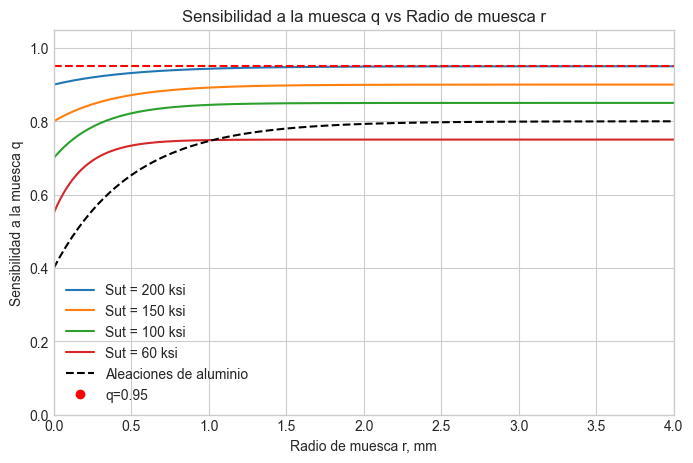

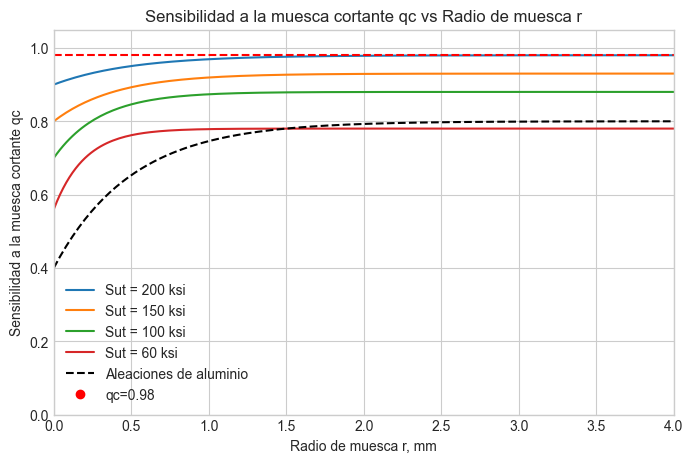

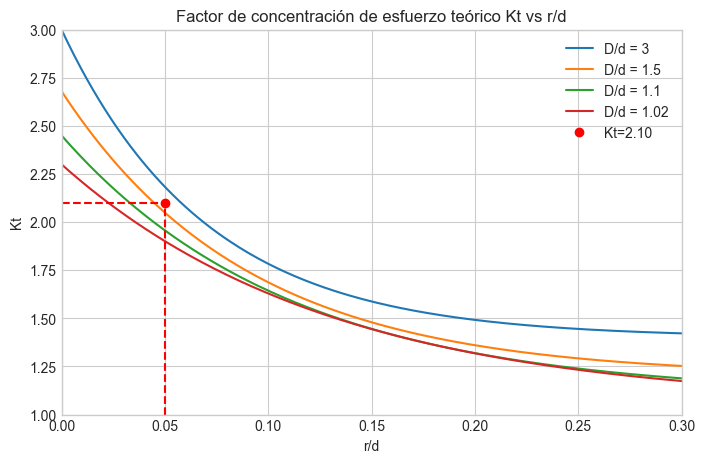

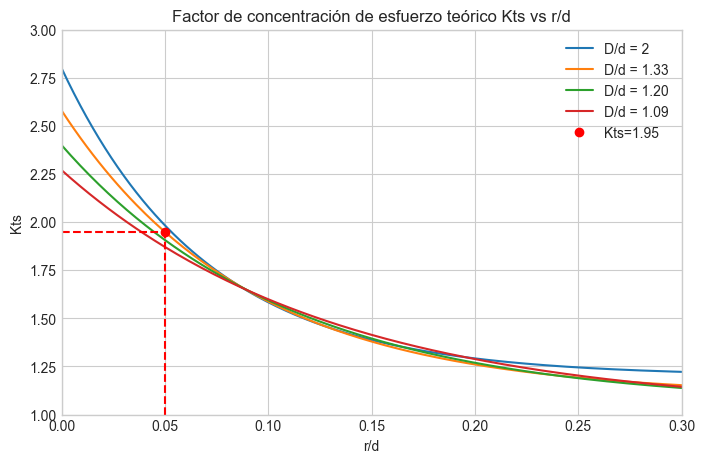

In [30]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
 
# --- Parámetros de ejemplo ---
r # pulgadas
Sut  # ksi
D  # pulgadas
d # pulgadas
rd = r/d
Dd_kt = kt # para Kt (flexión)
Dd_kts = kts # para Kts (torsión), se usará la curva más cercana (1.33)
 
# --- Funciones de curvas ---
def curva_q(r_mm, Sut):
    if Sut == 200:
        return 0.95 - 0.05 * np.exp(-r_mm/0.5)
    elif Sut == 150:
        return 0.90 - 0.10 * np.exp(-r_mm/0.4)
    elif Sut == 100:
        return 0.85 - 0.15 * np.exp(-r_mm/0.3)
    elif Sut == 60:
        return 0.75 - 0.20 * np.exp(-r_mm/0.2)
    else:
        if Sut < 60: Sut = 60
        if Sut > 200: Sut = 200
        q_60 = curva_q(r_mm, 60)
        q_100 = curva_q(r_mm, 100)
        q_150 = curva_q(r_mm, 150)
        q_200 = curva_q(r_mm, 200)
        if Sut <= 100:
            return q_60 + (q_100 - q_60) * (Sut-60)/(100-60)
        elif Sut <= 150:
            return q_100 + (q_150 - q_100) * (Sut-100)/(150-100)
        else:
            return q_150 + (q_200 - q_150) * (Sut-150)/(200-150)
 
def curva_qc(r_mm, Sut):
    if Sut == 200:
        return 0.98 - 0.08 * np.exp(-r_mm/0.5)
    elif Sut == 150:
        return 0.93 - 0.13 * np.exp(-r_mm/0.4)
    elif Sut == 100:
        return 0.88 - 0.18 * np.exp(-r_mm/0.3)
    elif Sut == 60:
        return 0.78 - 0.22 * np.exp(-r_mm/0.2)
    else:
        if Sut < 60: Sut = 60
        if Sut > 200: Sut = 200
        qc_60 = curva_qc(r_mm, 60)
        qc_100 = curva_qc(r_mm, 100)
        qc_150 = curva_qc(r_mm, 150)
        qc_200 = curva_qc(r_mm, 200)
        if Sut <= 100:
            return qc_60 + (qc_100 - qc_60) * (Sut-60)/(100-60)
        elif Sut <= 150:
            return qc_100 + (qc_150 - qc_100) * (Sut-100)/(150-100)
        else:
            return qc_150 + (qc_200 - qc_150) * (Sut-150)/(200-150)
 
def curva_kt(rd, Dd):
    if Dd == 3:
        return 1.4 + 1.6 * np.exp(-rd/0.07)
    elif Dd == 1.5:
        return 1.2 + 1.48 * np.exp(-rd/0.09)
    elif Dd == 1.1:
        return 1.1 + 1.35 * np.exp(-rd/0.11)
    elif Dd == 1.02:
        return 1.05 + 1.25 * np.exp(-rd/0.13)
    else:
        if Dd < 1.02: Dd = 1.02
        if Dd > 3: Dd = 3
        kt_102 = curva_kt(rd, 1.02)
        kt_11 = curva_kt(rd, 1.1)
        kt_15 = curva_kt(rd, 1.5)
        kt_3 = curva_kt(rd, 3)
        if Dd <= 1.1:
            return kt_102 + (kt_11 - kt_102) * (Dd-1.02)/(1.1-1.02)
        elif Dd <= 1.5:
            return kt_11 + (kt_15 - kt_11) * (Dd-1.1)/(1.5-1.1)
        else:
            return kt_15 + (kt_3 - kt_15) * (Dd-1.5)/(3-1.5)
 
def curva_kts(rd, Dd):
    if Dd == 2:
        return 1.2 + 1.6 * np.exp(-rd/0.07)
    elif Dd == 1.33:
        return 1.1 + 1.48 * np.exp(-rd/0.09)
    elif Dd == 1.20:
        return 1.05 + 1.35 * np.exp(-rd/0.11)
    elif Dd == 1.09:
        return 1.02 + 1.25 * np.exp(-rd/0.13)
    else:
        if Dd < 1.09: Dd = 1.09
        if Dd > 2: Dd = 2
        kts_109 = curva_kts(rd, 1.09)
        kts_120 = curva_kts(rd, 1.20)
        kts_133 = curva_kts(rd, 1.33)
        kts_2 = curva_kts(rd, 2)
        if Dd <= 1.20:
            return kts_109 + (kts_120 - kts_109) * (Dd-1.09)/(1.20-1.09)
        elif Dd <= 1.33:
            return kts_120 + (kts_133 - kts_120) * (Dd-1.20)/(1.33-1.20)
        else:
            return kts_133 + (kts_2 - kts_133) * (Dd-1.33)/(2-1.33)
 
# --- Gráfica 1: q (flexión) ---
r_mm = r * 25.4
r_mm_vec = np.linspace(0, 4, 200)
plt.figure(figsize=(8,5))
for Sut_val, label in zip([200,150,100,60], ['200','150','100','60']):
    plt.plot(r_mm_vec, curva_q(r_mm_vec, Sut_val), label=f'Sut = {label} ksi')
plt.plot(r_mm_vec, 0.4 + 0.4*(1-np.exp(-r_mm_vec/0.5)), 'k--', label='Aleaciones de aluminio')
q_ejemplo = float(curva_q(r_mm, Sut))
plt.axvline(r_mm, color='red', linestyle='--', ymax=(q_ejemplo-0.0)/1.05)
plt.axhline(q_ejemplo, color='red', linestyle='--', xmax=(r_mm/4))
plt.plot(r_mm, q_ejemplo, 'ro', label=f'q={q_ejemplo:.2f}')
plt.xlabel('Radio de muesca r, mm')
plt.ylabel('Sensibilidad a la muesca q')
plt.title('Sensibilidad a la muesca q vs Radio de muesca r')
plt.ylim(0.0, 1.05)
plt.xlim(0, 4)
plt.legend()
plt.grid(True)
plt.show()
 
# --- Gráfica 2: qc (torsión) ---
plt.figure(figsize=(8,5))
for Sut_val, label in zip([200,150,100,60], ['200','150','100','60']):
    plt.plot(r_mm_vec, curva_qc(r_mm_vec, Sut_val), label=f'Sut = {label} ksi')
plt.plot(r_mm_vec, 0.4 + 0.4*(1-np.exp(-r_mm_vec/0.5)), 'k--', label='Aleaciones de aluminio')
qc_ejemplo = float(curva_qc(r_mm, Sut))
plt.axvline(r_mm, color='red', linestyle='--', ymax=(qc_ejemplo-0.0)/1.05)
plt.axhline(qc_ejemplo, color='red', linestyle='--', xmax=(r_mm/4))
plt.plot(r_mm, qc_ejemplo, 'ro', label=f'qc={qc_ejemplo:.2f}')
plt.xlabel('Radio de muesca r, mm')
plt.ylabel('Sensibilidad a la muesca cortante qc')
plt.title('Sensibilidad a la muesca cortante qc vs Radio de muesca r')
plt.ylim(0.0, 1.05)
plt.xlim(0, 4)
plt.legend()
plt.grid(True)
plt.show()
 
# --- Gráfica 3: Kt (flexión) ---
rd_vec = np.linspace(0, 0.3, 200)
plt.figure(figsize=(8,5))
for Dd, label in zip([3,1.5,1.1,1.02], ['3','1.5','1.1','1.02']):
    plt.plot(rd_vec, curva_kt(rd_vec, Dd), label=f'D/d = {label}')
kt_ejemplo = float(curva_kt(rd, Dd_kt))
plt.axvline(rd, color='red', linestyle='--', ymax=(kt_ejemplo-1.0)/2.0)
plt.axhline(kt_ejemplo, color='red', linestyle='--', xmax=(rd/0.3))
plt.plot(rd, kt_ejemplo, 'ro', label=f'Kt={kt_ejemplo:.2f}')
plt.xlabel('r/d')
plt.ylabel('Kt')
plt.title('Factor de concentración de esfuerzo teórico Kt vs r/d')
plt.ylim(1.0, 3.0)
plt.xlim(0, 0.3)
plt.legend()
plt.grid(True)
plt.show()
 
# --- Gráfica 4: Kts (torsión) ---
plt.figure(figsize=(8,5))
for Dd, label in zip([2,1.33,1.20,1.09], ['2','1.33','1.20','1.09']):
    plt.plot(rd_vec, curva_kts(rd_vec, Dd), label=f'D/d = {label}')
kts_ejemplo = float(curva_kts(rd, 1.33)) # Se usa la curva más cercana
plt.axvline(rd, color='red', linestyle='--', ymax=(kts_ejemplo-1.0)/2.0)
plt.axhline(kts_ejemplo, color='red', linestyle='--', xmax=(rd/0.3))
plt.plot(rd, kts_ejemplo, 'ro', label=f'Kts={kts_ejemplo:.2f}')
plt.xlabel('r/d')
plt.ylabel('Kts')
plt.title('Factor de concentración de esfuerzo teórico Kts vs r/d')
plt.ylim(1.0, 3.0)
plt.xlim(0, 0.3)
plt.legend()
plt.grid(True)
plt.show()